In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

# Select one fund
fund = nav[nav["amfi_code"] == nav["amfi_code"].iloc[0]].copy()

fund = fund.sort_values("date")

fund["daily_return"] = fund["nav"].pct_change()

fund = fund.dropna()

fund.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [6]:
mean_return = fund["daily_return"].mean()
volatility = fund["daily_return"].std()

print("Mean Daily Return:", mean_return)
print("Daily Volatility:", volatility)

Mean Daily Return: 0.00014159930699210853
Daily Volatility: 0.009164463506291045


In [7]:
num_simulations = 100
trading_days = 252 * 5  # 5 years

last_nav = fund["nav"].iloc[-1]

simulations = np.zeros((trading_days, num_simulations))

for i in range(num_simulations):

    prices = [last_nav]

    for day in range(trading_days):

        shock = np.random.normal(mean_return, volatility)

        next_price = prices[-1] * (1 + shock)

        prices.append(next_price)

    simulations[:, i] = prices[1:]

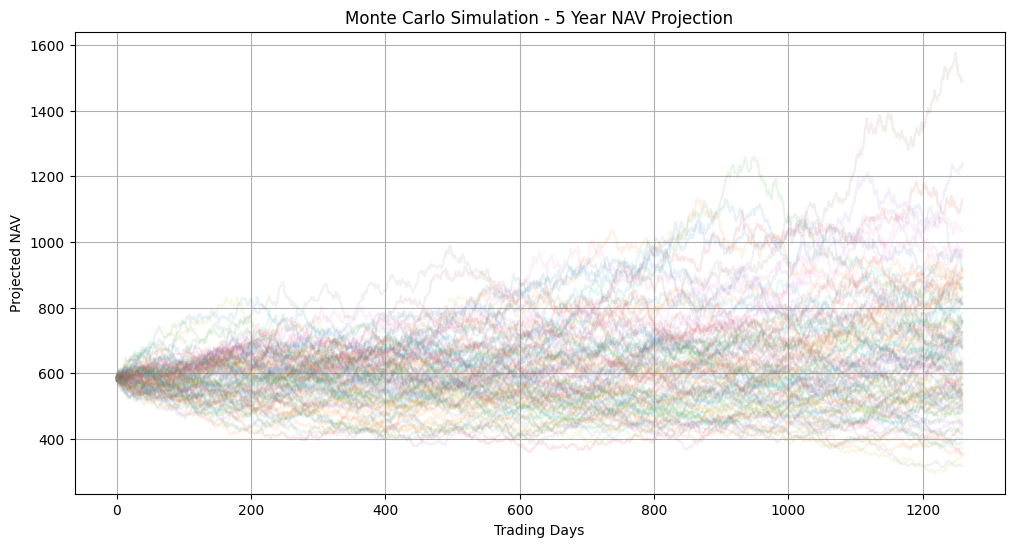

In [8]:
plt.figure(figsize=(12,6))

plt.plot(simulations, alpha=0.1)

plt.title("Monte Carlo Simulation - 5 Year NAV Projection")

plt.xlabel("Trading Days")

plt.ylabel("Projected NAV")

plt.grid(True)

plt.savefig(
    "../reports/monte_carlo_projection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
final_values = simulations[-1]

print("5th Percentile :", np.percentile(final_values, 5))
print("Median :", np.percentile(final_values, 50))
print("95th Percentile :", np.percentile(final_values, 95))

5th Percentile : 387.37737080480935
Median : 629.6292896813106
95th Percentile : 968.1159956883592


## Monte Carlo Simulation Summary

- Simulated 100 possible NAV paths over 5 years.
- Daily returns were modeled using historical mean and volatility.
- Projection includes uncertainty through random market movements.
- Final distribution provides downside, median, and upside scenarios.
- Useful for long-term mutual fund risk assessment.